# 2. CNN 구조 파악

이 노트북은 합성곱 신경망(CNN, Convolutional Neural Network)의 핵심 개념을 이해하고, 같은 MNIST 분류 문제를 ANN과 비교하면서 왜 CNN이 이미지 데이터에서 더 강력한지 확인하는 예제를 담고 있습니다.

> GPU가 잡히지 않아 `Using device: cpu`가 나온다면 먼저 `00_Torch_GPU_셋업.ipynb`를 확인하세요.

## 목차

- [2-1. CNN에 대한 기본 설명](#2-1.-CNN에-대한-기본-설명)
- [2-2. ANN과 비교했을 때 CNN이 강력한 이유](#2-2.-ANN과-비교했을-때-CNN이-강력한-이유)
- [2-3. MNIST 숫자 데이터셋 CNN 학습 예시](#2-3.-MNIST-숫자-데이터셋-CNN-학습-예시)


## 2-1. CNN에 대한 기본 설명

CNN은 이미지처럼 공간적인 구조를 가진 데이터를 다루기 위해 설계된 신경망입니다. ANN은 이미지를 1차원 벡터로 펼쳐서 처리하지만, CNN은 `(채널, 높이, 너비)` 구조를 유지한 채로 학습합니다.

### 1) 기본 구성

- **합성곱 층(Convolution Layer)**: 작은 필터(kernel)를 이미지 위로 이동시키며 특징을 추출합니다.
- **활성화 함수(ReLU 등)**: 비선형성을 추가해 복잡한 패턴을 학습하게 만듭니다.
- **풀링 층(Pooling Layer)**: 중요한 특징은 유지하면서 크기를 줄여 계산량과 과적합 위험을 낮춥니다.
- **완전연결층(Fully Connected Layer)**: 마지막에 추출된 특징을 이용해 최종 분류를 수행합니다.

### 2) 합성곱의 직관

예를 들어 `3 x 3` 필터는 이미지의 작은 영역만 보면서 선, 모서리, 획(stroke) 같은 지역적 특징을 감지합니다. 앞쪽 층에서는 단순한 특징을, 뒤쪽 층에서는 더 복잡한 숫자 모양을 조합해 학습합니다.


## 2-2. ANN과 비교했을 때 CNN이 강력한 이유

같은 MNIST 이미지라도 ANN과 CNN은 입력을 바라보는 방식이 다릅니다.

### 1) 공간 구조를 보존한다

- ANN은 `28 x 28` 이미지를 `784`차원 벡터로 펼칩니다.
- 이 과정에서 **가까이 있는 픽셀끼리의 관계**가 약해집니다.
- CNN은 이미지를 그대로 두고 주변 픽셀 패턴을 함께 봅니다.

### 2) 지역 특징을 잘 잡는다

- 숫자 `3`, `5`, `8`을 구분할 때는 전체 픽셀보다 **획의 방향, 모서리, 곡선**이 더 중요합니다.
- CNN의 필터는 바로 이런 지역 특징을 자동으로 학습합니다.

### 3) 같은 패턴을 여러 위치에서 재사용한다

- ANN은 입력 위치마다 거의 독립적으로 가중치를 둡니다.
- CNN은 하나의 필터를 이미지 전체에 공유합니다.
- 그래서 왼쪽 위에 있든 오른쪽 아래에 있든 비슷한 획을 같은 방식으로 감지할 수 있습니다.

### 4) 파라미터 수를 줄일 수 있다

- ANN은 첫 층부터 `784 x 256` 같은 큰 가중치 행렬이 필요합니다.
- CNN은 작은 필터를 공유하므로 더 적은 파라미터로도 강한 표현력을 얻을 수 있습니다.

결론적으로, **이미지처럼 위치 관계가 중요한 데이터에서는 CNN이 ANN보다 더 자연스럽고 효율적인 방식으로 특징을 학습**합니다.


In [ ]:
# 필요한 라이브러리가 없다면 아래 주석을 해제해서 설치하세요.
# !pip install torch torchvision matplotlib


## 2-3. MNIST 숫자 데이터셋 CNN 학습 예시

이번 예제에서는 PyTorch를 사용해서 간단한 CNN 분류기를 만들고 MNIST를 학습합니다. 또한 같은 입력을 받는 간단한 ANN과 파라미터 수를 비교해서 CNN의 효율성도 같이 확인합니다.


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

print('PyTorch version:', torch.__version__)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)


PyTorch version: 2.6.0+cu124
Using device: cuda


### 1) 데이터 준비

MNIST는 `28 x 28` 크기의 흑백 손글씨 숫자 이미지 데이터셋입니다. CNN은 이미지 형태를 유지한 채 입력받기 때문에 `(1, 28, 28)` 텐서를 그대로 사용합니다.


In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

print('Train samples:', len(train_dataset))
print('Test samples:', len(test_dataset))


Train samples: 60000
Test samples: 10000


배치 이미지 shape: torch.Size([64, 1, 28, 28])
배치 라벨 shape: torch.Size([64])


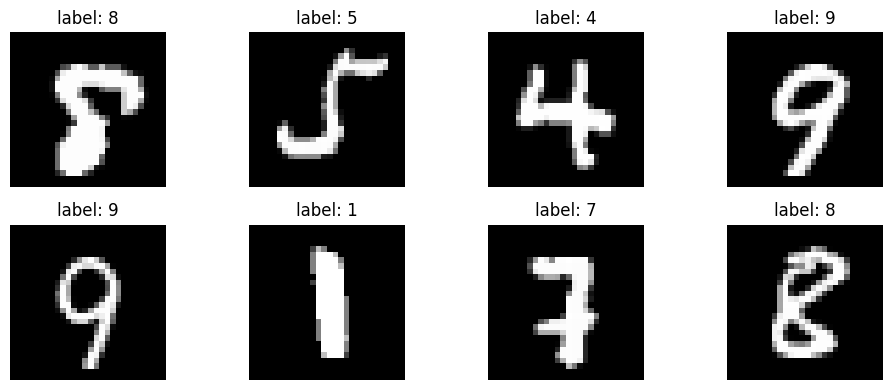

In [3]:
images, labels = next(iter(train_loader))
print('배치 이미지 shape:', images.shape)
print('배치 라벨 shape:', labels.shape)

plt.figure(figsize=(10, 4))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title(f'label: {labels[i].item()}')
    plt.axis('off')
plt.tight_layout()
plt.show()


### 2) ANN과 CNN 구조 비교

같은 MNIST라도 ANN은 이미지를 펼쳐서 처리하고, CNN은 이미지 형태를 유지한 채 특징을 추출합니다. 아래 코드는 두 모델의 구조와 파라미터 수를 비교합니다.


In [4]:
class SimpleANN(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.model(x)


class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


ann_model = SimpleANN()
cnn_model = SimpleCNN()

print('ANN 파라미터 수:', f"{count_parameters(ann_model):,}")
print('CNN 파라미터 수:', f"{count_parameters(cnn_model):,}")
print()
print('ANN 구조')
print(ann_model)
print()
print('CNN 구조')
print(cnn_model)


ANN 파라미터 수: 235,146
CNN 파라미터 수: 206,922

ANN 구조
SimpleANN(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=10, bias=True)
  )
)

CNN 구조
SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


위 비교에서 확인할 핵심은 다음과 같습니다.

- ANN은 시작부터 큰 완전연결층을 사용합니다.
- CNN은 작은 필터로 특징을 뽑고, 그 뒤에 분류기를 붙입니다.
- 즉, CNN은 **이미지 구조를 활용하면서도 파라미터를 효율적으로 사용**합니다.


### 3) CNN 모델 정의

이번 실습에서는 다음 구조를 사용합니다.

- `Conv2d(1, 16, 3, padding=1)`
- `ReLU`
- `MaxPool2d(2)`
- `Conv2d(16, 32, 3, padding=1)`
- `ReLU`
- `MaxPool2d(2)`
- `Flatten`
- `Linear(32 x 7 x 7, 128)`
- `Linear(128, 10)`

풀링을 두 번 거치면 입력 크기 `28 x 28`은 `14 x 14`, 다시 `7 x 7`로 줄어듭니다.


In [5]:
model = SimpleCNN().to(device)
print(model)


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


### 4) 손실 함수와 옵티마이저 설정

다중 분류 문제이므로 손실 함수는 `CrossEntropyLoss`를 사용합니다. 옵티마이저는 `Adam`을 사용합니다.


In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


### 5) 학습 함수와 평가 함수 정의

학습 단계에서는 배치 단위로 예측, 손실 계산, 역전파, 가중치 업데이트를 반복합니다.


In [7]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        predictions = outputs.argmax(dim=1)
        total += labels.size(0)
        correct += (predictions == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            predictions = outputs.argmax(dim=1)
            total += labels.size(0)
            correct += (predictions == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


### 6) 모델 학습

5 epoch 정도만 실행해도 CNN이 MNIST를 매우 안정적으로 분류하는 것을 확인할 수 있습니다. 일반적으로 같은 조건이라면 CNN이 ANN보다 더 높은 정확도와 더 나은 일반화 성능을 보이는 경우가 많습니다.


In [8]:
epochs = 5
history = {
    'train_loss': [],
    'train_acc': [],
    'test_loss': [],
    'test_acc': []
}

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)

    print(
        f'Epoch [{epoch + 1}/{epochs}] | '
        f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | '
        f'Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}'
    )


Epoch [1/5] | Train Loss: 0.1659, Train Acc: 0.9512 | Test Loss: 0.0546, Test Acc: 0.9808
Epoch [2/5] | Train Loss: 0.0499, Train Acc: 0.9847 | Test Loss: 0.0434, Test Acc: 0.9867
Epoch [3/5] | Train Loss: 0.0345, Train Acc: 0.9891 | Test Loss: 0.0334, Test Acc: 0.9884
Epoch [4/5] | Train Loss: 0.0261, Train Acc: 0.9918 | Test Loss: 0.0355, Test Acc: 0.9886
Epoch [5/5] | Train Loss: 0.0209, Train Acc: 0.9932 | Test Loss: 0.0296, Test Acc: 0.9898


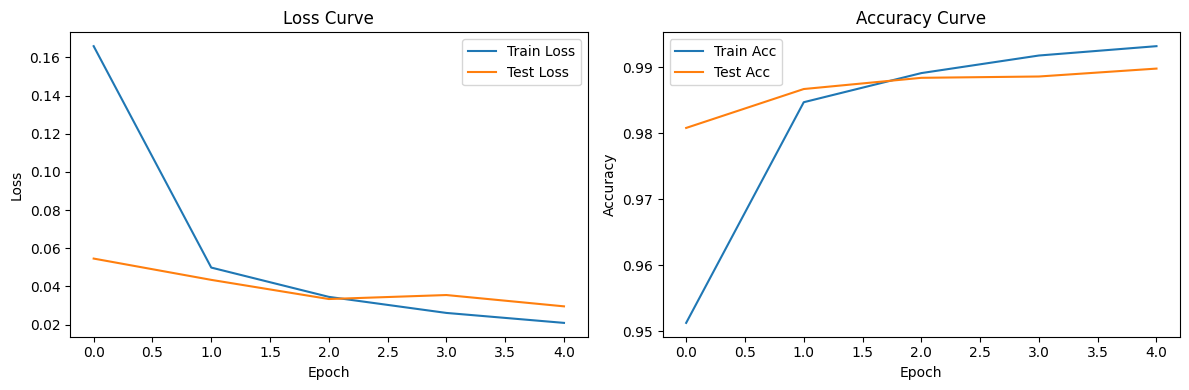

In [9]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['test_loss'], label='Test Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['test_acc'], label='Test Acc')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


### 7) 합성곱 특징맵(feature map) 확인

CNN이 강력한 이유는 단순히 정확도가 높아서만이 아니라, 중간 층에서 이미지의 특징을 실제로 추출하기 때문입니다. 아래에서는 첫 번째 합성곱 층의 출력 일부를 시각화합니다.


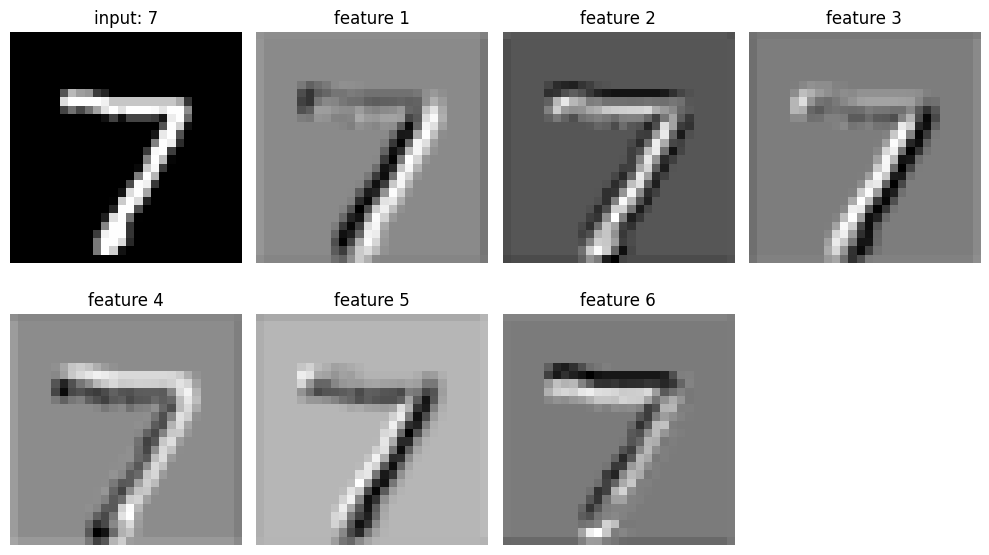

In [10]:
model.eval()
sample_image, sample_label = test_dataset[0]
input_tensor = sample_image.unsqueeze(0).to(device)

with torch.no_grad():
    feature_maps = model.features[0](input_tensor)

feature_maps = feature_maps.cpu().squeeze(0)

plt.figure(figsize=(10, 6))
plt.subplot(2, 4, 1)
plt.imshow(sample_image.squeeze(), cmap='gray')
plt.title(f'input: {sample_label}')
plt.axis('off')

for i in range(6):
    plt.subplot(2, 4, i + 2)
    plt.imshow(feature_maps[i], cmap='gray')
    plt.title(f'feature {i + 1}')
    plt.axis('off')

plt.tight_layout()
plt.show()


위 결과를 보면 필터마다 서로 다른 반응을 보입니다. 어떤 필터는 경계선에, 어떤 필터는 밝은 획에, 어떤 필터는 특정 방향의 패턴에 더 강하게 반응합니다. 이것이 ANN보다 CNN이 이미지 특징을 더 잘 다루는 이유입니다.


### 8) 테스트 데이터로 예측 확인

학습이 끝난 뒤에는 테스트 이미지 몇 장을 직접 넣어 실제 예측 결과를 확인할 수 있습니다.


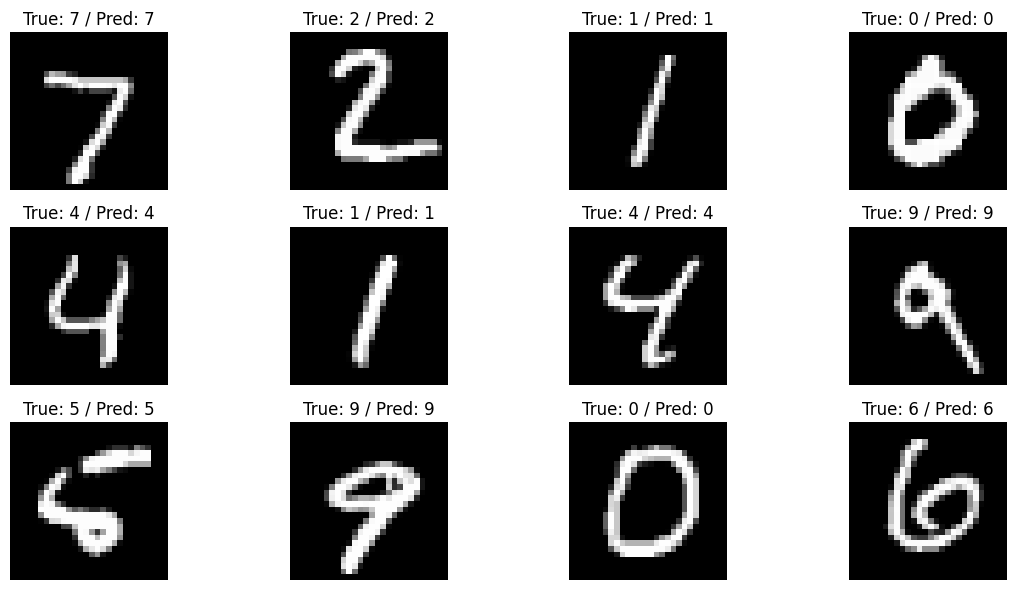

In [12]:
model.eval()
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    outputs = model(images)
    predictions = outputs.argmax(dim=1)

images = images.cpu()
labels = labels.cpu()
predictions = predictions.cpu()

plt.figure(figsize=(12, 6))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title(f'True: {labels[i].item()} / Pred: {predictions[i].item()}')
    plt.axis('off')

plt.tight_layout()
plt.show()


## 정리

이번 노트북에서 확인한 핵심은 다음과 같습니다.

- ANN은 이미지를 펼쳐서 처리하지만, CNN은 이미지의 공간 구조를 유지합니다.
- CNN은 작은 필터로 지역 특징을 학습하고, 이를 여러 위치에 공유합니다.
- 이런 구조 덕분에 CNN은 이미지 데이터에서 더 효율적으로 특징을 추출합니다.
- 같은 MNIST 분류 문제에서도 CNN은 ANN보다 더 자연스럽게 이미지 패턴을 학습할 수 있습니다.
- feature map을 보면 CNN이 실제로 숫자의 획과 경계 같은 정보를 중간 층에서 추출하고 있음을 확인할 수 있습니다.

다음 단계에서는 더 깊은 CNN, 데이터 증강, 드롭아웃 등을 추가하면서 성능을 더 높여볼 수 있습니다.
